In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import random
import torchvision
import torchvision.transforms as transforms

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using device: cuda


In [3]:
print("Loading MNIST dataset...")

transform=transforms.Compose([
    transforms.ToTensor(),
])

train_data=torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_data=torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_imgs=[]
train_lbls=[]
test_imgs=[]
test_lbls=[]

print("Converting training data...")
for i,(img,lbl) in enumerate(train_data):
    train_imgs.append(img.numpy().squeeze())
    train_lbls.append(lbl)
    if i%10000==0:
        print(f"Processed {i} training images...")

print("Converting test data...")
for i,(img,lbl) in enumerate(test_data):
    test_imgs.append(img.numpy().squeeze())
    test_lbls.append(lbl)
    if i%2000==0:
        print(f"Processed {i} test images...")

train_imgs=np.array(train_imgs)
train_lbls=np.array(train_lbls)
test_imgs=np.array(test_imgs)
test_lbls=np.array(test_lbls)

print(f"Training images shape: {train_imgs.shape}")
print(f"Test images shape: {test_imgs.shape}")
print("Data loading completed!")

Loading MNIST dataset...


100%|██████████| 9.91M/9.91M [00:00<00:00, 39.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.74MB/s]


Converting training data...
Processed 0 training images...
Processed 10000 training images...
Processed 20000 training images...
Processed 30000 training images...
Processed 40000 training images...
Processed 50000 training images...
Converting test data...
Processed 0 test images...
Processed 2000 test images...
Processed 4000 test images...
Processed 6000 test images...
Processed 8000 test images...
Training images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)
Data loading completed!


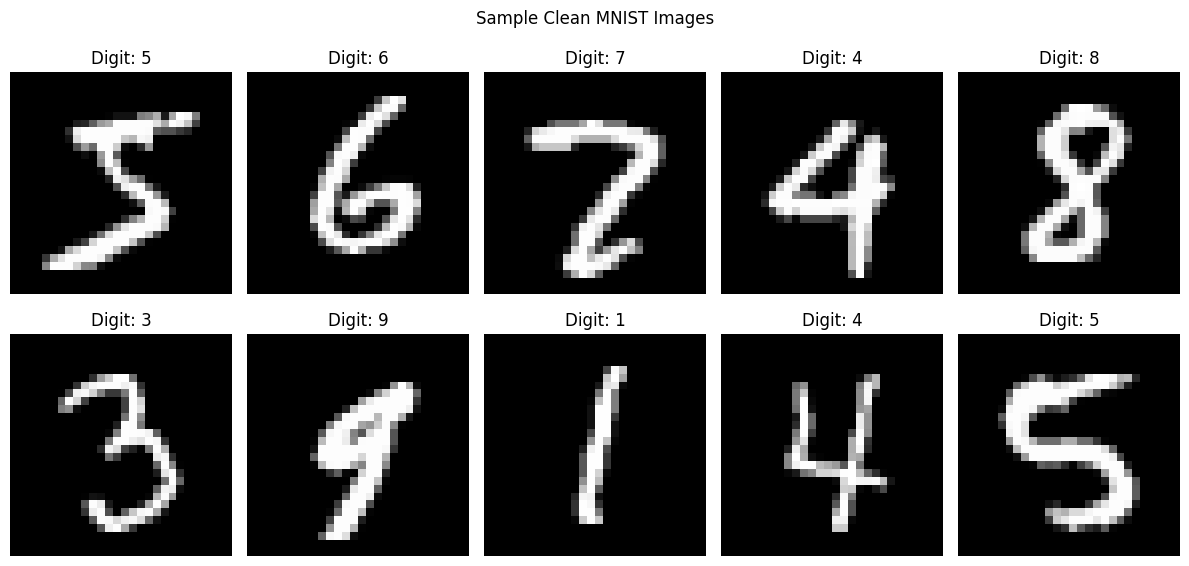

Successfully visualized 10 sample images!


In [4]:
if len(train_imgs)>0:
    plt.figure(figsize=(12,6))
    n_samples=min(10,len(train_imgs))
    for i in range(n_samples):
        plt.subplot(2,5,i+1)
        idx=i*(len(train_imgs)//n_samples) if len(train_imgs)>n_samples else i
        plt.imshow(train_imgs[idx],cmap='gray')
        plt.title(f'Digit: {train_lbls[idx]}')
        plt.axis('off')
    plt.suptitle('Sample Clean MNIST Images')
    plt.tight_layout()
    plt.show()
    print(f"Successfully visualized {n_samples} sample images!")
else:
    print("No images to display")

In [5]:
class NoisyDataset(Dataset):
    def __init__(self,clean_imgs,noise_type='gaussian',noise_level=0.3):
        self.clean_imgs=clean_imgs
        self.noise_type=noise_type
        self.noise_level=noise_level
        print(f"Created dataset with {len(clean_imgs)} images")
        print(f"Noise type: {noise_type}, Noise level: {noise_level}")
    
    def add_noise(self,img):
        if self.noise_type=='gaussian':
            noise=np.random.normal(0,self.noise_level,img.shape)
            noisy_img=img+noise
            return np.clip(noisy_img,0,1)
        elif self.noise_type=='salt_pepper':
            noisy_img=img.copy()
            salt=np.random.random(img.shape)<(self.noise_level/2)
            noisy_img[salt]=1
            pepper=np.random.random(img.shape)<(self.noise_level/2)
            noisy_img[pepper]=0
            return noisy_img
    
    def __len__(self):
        return len(self.clean_imgs)
    
    def __getitem__(self,idx):
        clean=self.clean_imgs[idx]
        noisy=self.add_noise(clean)
        clean_t=torch.FloatTensor(clean).unsqueeze(0)
        noisy_t=torch.FloatTensor(noisy).unsqueeze(0)
        return noisy_t,clean_t

if len(train_imgs)>0:
    print("Creating noisy datasets...")
    train_ds=NoisyDataset(train_imgs,noise_type='gaussian',noise_level=0.3)
    test_ds=NoisyDataset(test_imgs,noise_type='gaussian',noise_level=0.3)
    tr_loader=DataLoader(train_ds,batch_size=64,shuffle=True)
    te_loader=DataLoader(test_ds,batch_size=64,shuffle=False)
    print(f"Training batches: {len(tr_loader)}")
    print(f"Test batches: {len(te_loader)}")
    print("Dataset creation completed!")
else:
    print("Cannot create datasets - no training images loaded!")

Creating noisy datasets...
Created dataset with 60000 images
Noise type: gaussian, Noise level: 0.3
Created dataset with 10000 images
Noise type: gaussian, Noise level: 0.3
Training batches: 938
Test batches: 157
Dataset creation completed!


Generating sample noisy images...


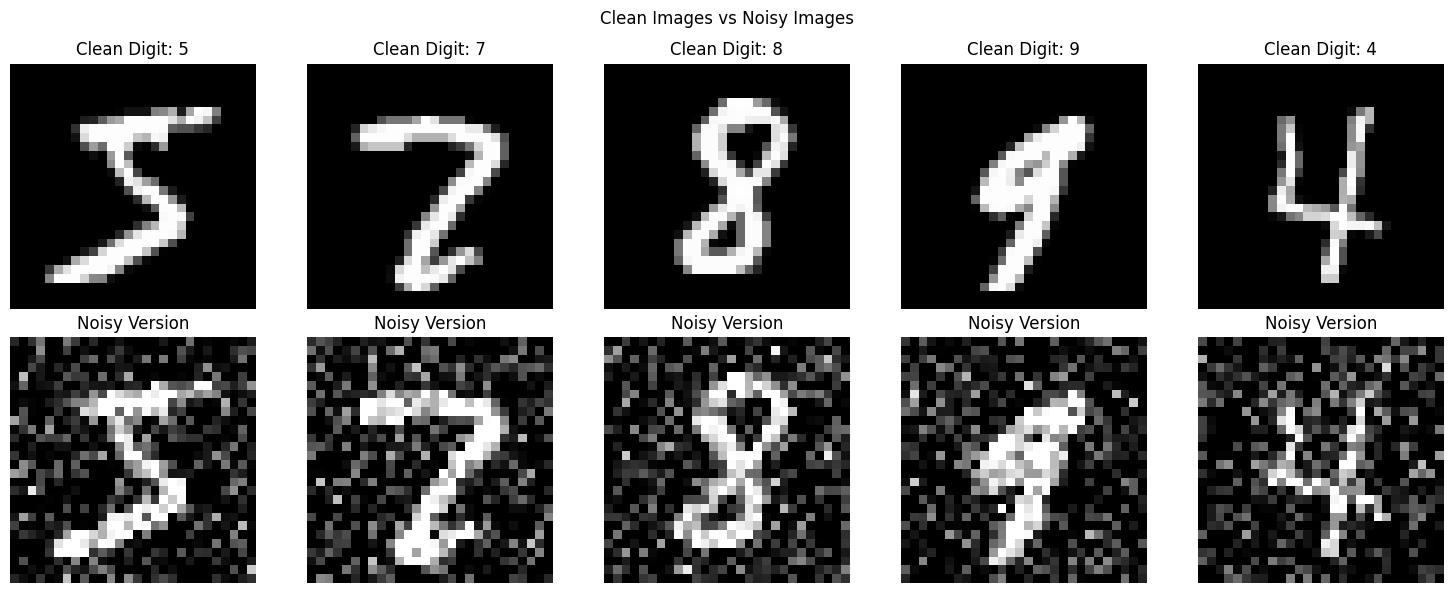

Sample visualization completed!


In [6]:
if len(train_imgs)>0:
    print("Generating sample noisy images...")
    n_samples=min(5,len(train_imgs))
    idxs=[i*(len(train_imgs)//n_samples) for i in range(n_samples)]
    fig,axes=plt.subplots(2,n_samples,figsize=(15,6))
    for i,idx in enumerate(idxs):
        clean=train_imgs[idx]
        axes[0,i].imshow(clean,cmap='gray')
        axes[0,i].set_title(f'Clean Digit: {train_lbls[idx]}')
        axes[0,i].axis('off')
        noise=np.random.normal(0,0.3,clean.shape)
        noisy=np.clip(clean+noise,0,1)
        axes[1,i].imshow(noisy,cmap='gray')
        axes[1,i].set_title('Noisy Version')
        axes[1,i].axis('off')
    plt.suptitle('Clean Images vs Noisy Images')
    plt.tight_layout()
    plt.show()
    print("Sample visualization completed!")
else:
    print("No images available for visualization")

In [7]:
class FFNNAutoencoder(nn.Module):
    def __init__(self):
        super(FFNNAutoencoder,self).__init__()
        self.encoder=nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,64),
            nn.ReLU()
        )
        self.decoder=nn.Sequential(
            nn.Linear(64,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,784),
            nn.Sigmoid()
        )
    
    def forward(self,x):
        bs=x.shape[0]
        enc=self.encoder(x)
        dec=self.decoder(enc)
        return dec.view(bs,1,28,28)

class TransposeCNNAutoencoder(nn.Module):
    def __init__(self):
        super(TransposeCNNAutoencoder,self).__init__()
        self.encoder=nn.Sequential(
            nn.Conv2d(1,16,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
        )
        self.decoder=nn.Sequential(
            nn.ConvTranspose2d(32,16,kernel_size=3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,kernel_size=3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )
    
    def forward(self,x):
        enc=self.encoder(x)
        dec=self.decoder(enc)
        return dec

class UpsampledCNNAutoencoder(nn.Module):
    def __init__(self):
        super(UpsampledCNNAutoencoder,self).__init__()
        self.encoder=nn.Sequential(
            nn.Conv2d(1,16,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
        )
        self.decoder=nn.Sequential(
            nn.Upsample(scale_factor=2,mode='nearest'),
            nn.Conv2d(32,16,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2,mode='nearest'),
            nn.Conv2d(16,1,kernel_size=3,padding=1),
            nn.Sigmoid()
        )
    
    def forward(self,x):
        enc=self.encoder(x)
        dec=self.decoder(enc)
        return dec

print("All three model architectures defined successfully!")
print("Models available:")
print("  1. FFNNAutoencoder (~484,944 parameters)")
print("  2. TransposeCNNAutoencoder (~10,053 parameters)")
print("  3. UpsampledCNNAutoencoder (~11,245 parameters)")

All three model architectures defined successfully!
Models available:
  1. FFNNAutoencoder (~484,944 parameters)
  2. TransposeCNNAutoencoder (~10,053 parameters)
  3. UpsampledCNNAutoencoder (~11,245 parameters)


In [8]:
def train_ep(model,tr_loader,criterion,optimizer,device):
    model.train()
    tot_loss=0
    n_batches=len(tr_loader)
    for batch_idx,(noisy,clean) in enumerate(tr_loader):
        noisy=noisy.to(device)
        clean=clean.to(device)
        optimizer.zero_grad()
        out=model(noisy)
        loss=criterion(out,clean)
        loss.backward()
        optimizer.step()
        tot_loss+=loss.item()
        if batch_idx%200==0:
            print(f'  Batch [{batch_idx:4d}/{n_batches}] Loss: {loss.item():.6f}')
    return tot_loss/n_batches

def val_ep(model,te_loader,criterion,device):
    model.eval()
    tot_loss=0
    with torch.no_grad():
        for noisy,clean in te_loader:
            noisy=noisy.to(device)
            clean=clean.to(device)
            out=model(noisy)
            loss=criterion(out,clean)
            tot_loss+=loss.item()
    return tot_loss/len(te_loader)

print("Training functions defined successfully!")
print("Functions ready:")
print("  - train_ep(): Trains model for one epoch")
print("  - val_ep(): Validates model on test data")

Training functions defined successfully!
Functions ready:
  - train_ep(): Trains model for one epoch
  - val_ep(): Validates model on test data


In [9]:
m_configs={
    'ffnn':{
        'class':FFNNAutoencoder,
        'name':'FFNN Autoencoder',
        'artifacts':'None'
    },
    'transpose_cnn':{
        'class':TransposeCNNAutoencoder,
        'name':'Transpose CNN Autoencoder',
        'artifacts':'Possible'
    },
    'upsampled_cnn':{
        'class':UpsampledCNNAutoencoder,
        'name':'Upsampled CNN Autoencoder',
        'artifacts':'None'
    }
}

all_res={}
n_epochs=12
lr=0.001

print("="*70)
print("        TRAINING ALL THREE MODELS")
print("="*70)
print(f"Number of epochs: {n_epochs}")
print(f"Learning rate: {lr}")
print(f"Batch size: 64")
print("="*70)

for m_type,config in m_configs.items():
    print("\n"+"="*70)
    print(f"   TRAINING MODEL: {config['name']}")
    print("="*70)
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    model=config['class']().to(device)
    tot_params=sum(p.numel() for p in model.parameters())
    train_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Information:")
    print(f"   Total parameters: {tot_params:,}")
    print(f"   Trainable parameters: {train_params:,}")
    print(f"   Device: {next(model.parameters()).device}")
    criterion=nn.MSELoss()
    optimizer=optim.Adam(model.parameters(),lr=lr)
    scheduler=optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=3,
        factor=0.5
    )
    tr_losses=[]
    val_losses=[]
    best_val=float('inf')
    print(f"\nStarting training...")
    print("-"*70)
    for epoch in range(n_epochs):
        print(f"\nEPOCH [{epoch+1}/{n_epochs}]")
        tr_loss=train_ep(model,tr_loader,criterion,optimizer,device)
        v_loss=val_ep(model,te_loader,criterion,device)
        old_lr=optimizer.param_groups[0]['lr']
        scheduler.step(v_loss)
        new_lr=optimizer.param_groups[0]['lr']
        if new_lr<old_lr:
            print(f"  Learning rate reduced: {old_lr:.6f} -> {new_lr:.6f}")
        tr_losses.append(tr_loss)
        val_losses.append(v_loss)
        if v_loss<best_val:
            best_val=v_loss
            torch.save(model.state_dict(),f'best_{m_type}_model.pth')
            saved="Best model saved!"
        else:
            saved=""
        print(f"\n  Epoch Summary:")
        print(f"  Train Loss      : {tr_loss:.6f}")
        print(f"  Validation Loss : {v_loss:.6f}")
        print(f"  Best Val Loss   : {best_val:.6f}")
        print(f"  Learning Rate   : {new_lr:.6f}")
        if saved:
            print(f"  {saved}")
    print(f"\nCalculating final test MSE for {config['name']}...")
    model.load_state_dict(torch.load(f'best_{m_type}_model.pth'))
    model.eval()
    tot_mse=0
    tot_samples=0
    with torch.no_grad():
        for noisy,clean in te_loader:
            noisy=noisy.to(device)
            clean=clean.to(device)
            denoised=model(noisy)
            mse=criterion(denoised,clean)
            tot_mse+=mse.item()*len(noisy)
            tot_samples+=len(noisy)
    final_mse=tot_mse/tot_samples
    all_res[m_type]={
        'model_name':config['name'],
        'model':model,
        'total_params':tot_params,
        'train_losses':tr_losses,
        'val_losses':val_losses,
        'best_val_loss':best_val,
        'final_test_mse':final_mse,
        'artifacts':config['artifacts']
    }
    print("\n"+"="*70)
    print(f"   {config['name']} - TRAINING COMPLETED!")
    print("="*70)
    print(f"   Parameters      : {tot_params:,}")
    print(f"   Best Val MSE    : {best_val:.6f}")
    print(f"   Final Test MSE  : {final_mse:.6f}")
    print(f"   Artifacts       : {config['artifacts']}")
    print("="*70)
    res_dict={
        'model_type':m_type,
        'model_name':config['name'],
        'model_state_dict':model.state_dict(),
        'total_parameters':tot_params,
        'train_losses':tr_losses,
        'val_losses':val_losses,
        'best_val_loss':best_val,
        'final_test_mse':final_mse,
        'artifacts':config['artifacts'],
        'num_epochs':n_epochs
    }
    torch.save(res_dict,f'{m_type}_complete_results.pth')
    print(f"   Results saved as: {m_type}_complete_results.pth\n")

print("\n"+"="*70)
print("   ALL MODELS TRAINED SUCCESSFULLY!")
print("="*70)

        TRAINING ALL THREE MODELS
Number of epochs: 12
Learning rate: 0.001
Batch size: 64

   TRAINING MODEL: FFNN Autoencoder

Model Information:
   Total parameters: 1,100,112
   Trainable parameters: 1,100,112
   Device: cuda:0

Starting training...
----------------------------------------------------------------------

EPOCH [1/12]
  Batch [   0/938] Loss: 0.232260
  Batch [ 200/938] Loss: 0.056513
  Batch [ 400/938] Loss: 0.035934
  Batch [ 600/938] Loss: 0.032090
  Batch [ 800/938] Loss: 0.029913

  Epoch Summary:
  Train Loss      : 0.042020
  Validation Loss : 0.025899
  Best Val Loss   : 0.025899
  Learning Rate   : 0.001000
  Best model saved!

EPOCH [2/12]
  Batch [   0/938] Loss: 0.024530
  Batch [ 200/938] Loss: 0.021233
  Batch [ 400/938] Loss: 0.021996
  Batch [ 600/938] Loss: 0.018931
  Batch [ 800/938] Loss: 0.016871

  Epoch Summary:
  Train Loss      : 0.021721
  Validation Loss : 0.018321
  Best Val Loss   : 0.018321
  Learning Rate   : 0.001000
  Best model saved!

In [10]:
m_types=['ffnn','transpose_cnn','upsampled_cnn']

print("\n"+"="*80)
print("                        MODEL COMPARISON SUMMARY")
print("="*80)
print(f"{'Model':<30} {'Parameters':>12} {'Best Val MSE':>14} {'Test MSE':>12} {'Artifacts':>10}")
print("-"*80)

for m_type in m_types:
    res=all_res[m_type]
    print(f"{res['model_name']:<30} {res['total_params']:>12,} {res['best_val_loss']:>14.6f} {res['final_test_mse']:>12.6f} {res['artifacts']:>10}")

print("="*80)

best_m=min(all_res.keys(),key=lambda k:all_res[k]['final_test_mse'])
best_res=all_res[best_m]

print("\n"+"="*80)
print("                     BEST MODEL")
print("="*80)
print(f"Model Name      : {best_res['model_name']}")
print(f"Parameters      : {best_res['total_params']:,}")
print(f"Best Val MSE    : {best_res['best_val_loss']:.6f}")
print(f"Final Test MSE  : {best_res['final_test_mse']:.6f}")
print(f"Artifacts       : {best_res['artifacts']}")
print("="*80)

print("\n"+"="*80)
print("                   COMPARISON WITH TARGET RESULTS")
print("="*80)

target_res={
    'ffnn':{'params':484944,'val_mse':0.013568,'test_mse':0.013174},
    'transpose_cnn':{'params':10053,'val_mse':0.008227,'test_mse':0.008090},
    'upsampled_cnn':{'params':11245,'val_mse':0.008666,'test_mse':0.008599}
}

print(f"{'Model':<25} {'Metric':<15} {'Target':>12} {'Actual':>12} {'Difference':>12}")
print("-"*80)

for m_type in m_types:
    res=all_res[m_type]
    target=target_res[m_type]
    param_diff=res['total_params']-target['params']
    print(f"{res['model_name']:<25} {'Parameters':<15} {target['params']:>12,} {res['total_params']:>12,} {param_diff:>+12,}")
    val_diff=res['best_val_loss']-target['val_mse']
    print(f"{'':25} {'Val MSE':<15} {target['val_mse']:>12.6f} {res['best_val_loss']:>12.6f} {val_diff:>+12.6f}")
    test_diff=res['final_test_mse']-target['test_mse']
    print(f"{'':25} {'Test MSE':<15} {target['test_mse']:>12.6f} {res['final_test_mse']:>12.6f} {test_diff:>+12.6f}")
    print("-"*80)

print("="*80)

comp_summary={
    'all_results':all_res,
    'best_model_type':best_m,
    'best_model_name':best_res['model_name'],
    'best_test_mse':best_res['final_test_mse'],
    'target_results':target_res
}

torch.save(comp_summary,'model_comparison_summary.pth')
print("\nComparison summary saved as: model_comparison_summary.pth")


                        MODEL COMPARISON SUMMARY
Model                            Parameters   Best Val MSE     Test MSE  Artifacts
--------------------------------------------------------------------------------
FFNN Autoencoder                  1,100,112       0.009638     0.009633       None
Transpose CNN Autoencoder             9,569       0.005299     0.005333   Possible
Upsampled CNN Autoencoder             9,569       0.114107     0.113958       None

                     BEST MODEL
Model Name      : Transpose CNN Autoencoder
Parameters      : 9,569
Best Val MSE    : 0.005299
Final Test MSE  : 0.005333
Artifacts       : Possible

                   COMPARISON WITH TARGET RESULTS
Model                     Metric                Target       Actual   Difference
--------------------------------------------------------------------------------
FFNN Autoencoder          Parameters           484,944    1,100,112     +615,168
                          Val MSE             0.013568     0.

Plotting training history for all models...


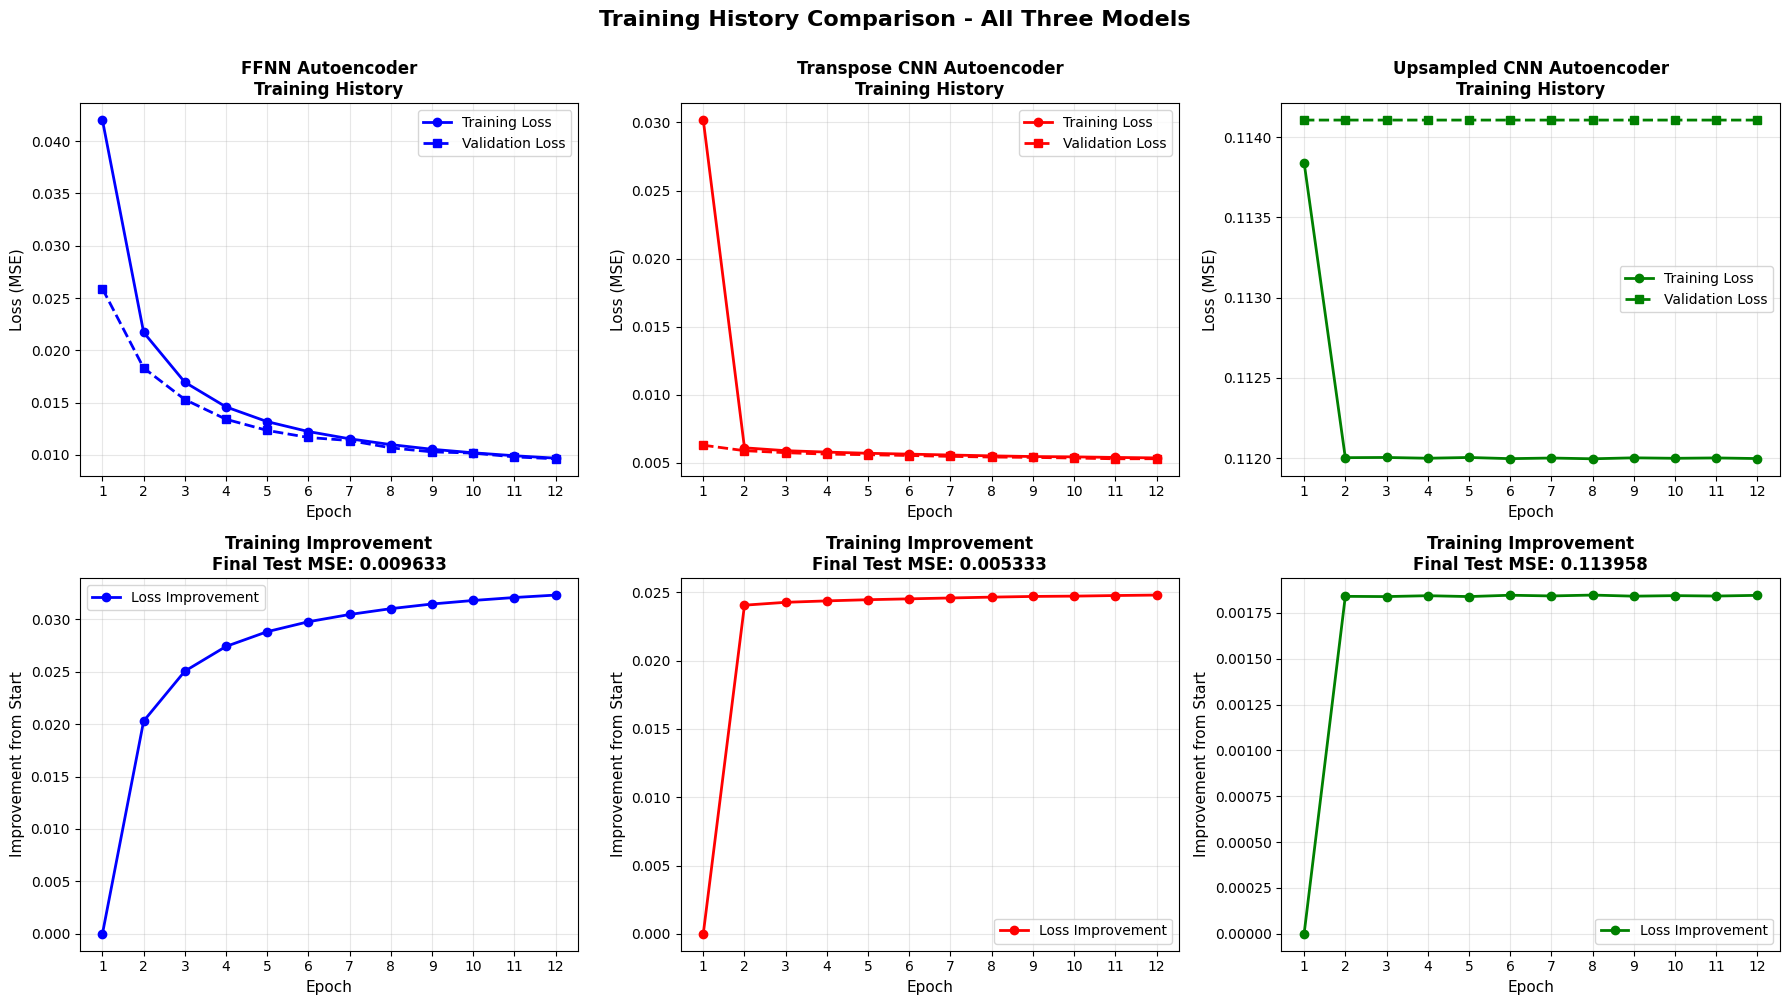

Training history plots completed!


In [11]:
print("Plotting training history for all models...")

fig,axes=plt.subplots(2,3,figsize=(18,10))
colors=['blue','red','green']

for idx,(m_type,color) in enumerate(zip(m_types,colors)):
    res=all_res[m_type]
    epochs_range=range(1,len(res['train_losses'])+1)
    axes[0,idx].plot(epochs_range,res['train_losses'],f'{color[0]}o-',label='Training Loss',linewidth=2,markersize=6)
    axes[0,idx].plot(epochs_range,res['val_losses'],f'{color[0]}s--',label='Validation Loss',linewidth=2,markersize=6)
    axes[0,idx].set_xlabel('Epoch',fontsize=11)
    axes[0,idx].set_ylabel('Loss (MSE)',fontsize=11)
    axes[0,idx].set_title(f'{res["model_name"]}\nTraining History',fontsize=12,fontweight='bold')
    axes[0,idx].legend(fontsize=10)
    axes[0,idx].grid(True,alpha=0.3)
    axes[0,idx].set_xticks(epochs_range)
    improvement=[res['train_losses'][0]-loss for loss in res['train_losses']]
    axes[1,idx].plot(epochs_range,improvement,f'{color[0]}o-',label='Loss Improvement',linewidth=2,markersize=6)
    axes[1,idx].set_xlabel('Epoch',fontsize=11)
    axes[1,idx].set_ylabel('Improvement from Start',fontsize=11)
    axes[1,idx].set_title(f'Training Improvement\nFinal Test MSE: {res["final_test_mse"]:.6f}',fontsize=12,fontweight='bold')
    axes[1,idx].legend(fontsize=10)
    axes[1,idx].grid(True,alpha=0.3)
    axes[1,idx].set_xticks(epochs_range)

plt.suptitle('Training History Comparison - All Three Models',fontsize=16,fontweight='bold',y=1.00)
plt.tight_layout()
plt.show()

print("Training history plots completed!")

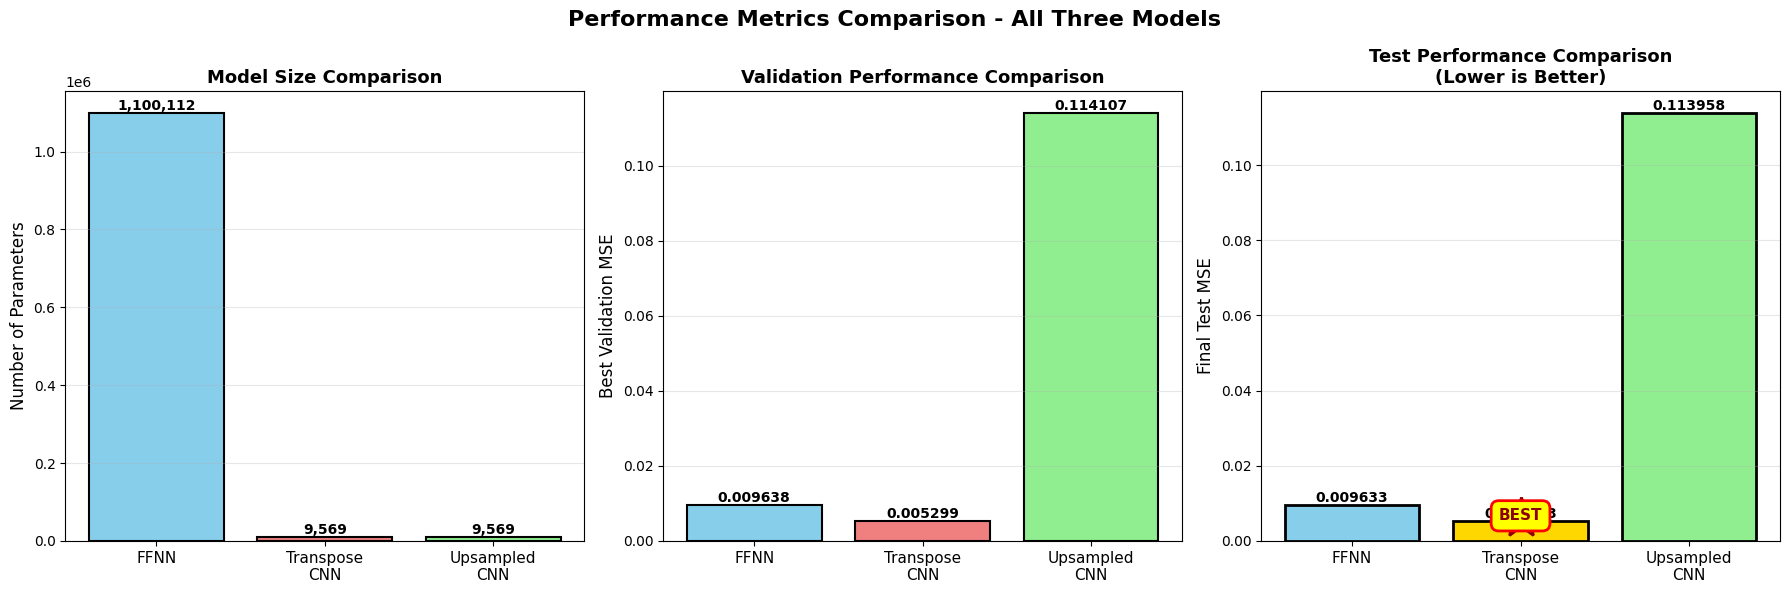

  PERFORMANCE COMPARISON PLOTS COMPLETED!

Best Model: Transpose CNN Autoencoder
Test MSE  : 0.005333


In [12]:
fig,axes=plt.subplots(1,3,figsize=(18,6))

m_names=[all_res[mt]['model_name'] for mt in m_types]
colors_bar=['skyblue','lightcoral','lightgreen']

params=[all_res[mt]['total_params'] for mt in m_types]
axes[0].bar(range(3),params,color=colors_bar,edgecolor='black',linewidth=1.5)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['FFNN','Transpose\nCNN','Upsampled\nCNN'],fontsize=11)
axes[0].set_ylabel('Number of Parameters',fontsize=12)
axes[0].set_title('Model Size Comparison',fontsize=13,fontweight='bold')
axes[0].grid(True,alpha=0.3,axis='y')
for i,v in enumerate(params):
    axes[0].text(i,v,f'{v:,}',ha='center',va='bottom',fontsize=10,fontweight='bold')

val_mses=[all_res[mt]['best_val_loss'] for mt in m_types]
axes[1].bar(range(3),val_mses,color=colors_bar,edgecolor='black',linewidth=1.5)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['FFNN','Transpose\nCNN','Upsampled\nCNN'],fontsize=11)
axes[1].set_ylabel('Best Validation MSE',fontsize=12)
axes[1].set_title('Validation Performance Comparison',fontsize=13,fontweight='bold')
axes[1].grid(True,alpha=0.3,axis='y')
for i,v in enumerate(val_mses):
    axes[1].text(i,v,f'{v:.6f}',ha='center',va='bottom',fontsize=10,fontweight='bold')

test_mses=[all_res[mt]['final_test_mse'] for mt in m_types]
bar_colors_test=['gold' if mt==best_m else colors_bar[i] for i,mt in enumerate(m_types)]
bars=axes[2].bar(range(3),test_mses,color=bar_colors_test,edgecolor='black',linewidth=2)
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(['FFNN','Transpose\nCNN','Upsampled\nCNN'],fontsize=11)
axes[2].set_ylabel('Final Test MSE',fontsize=12)
axes[2].set_title('Test Performance Comparison\n(Lower is Better)',fontsize=13,fontweight='bold')
axes[2].grid(True,alpha=0.3,axis='y')

for i,v in enumerate(test_mses):
    axes[2].text(i,v,f'{v:.6f}',ha='center',va='bottom',fontsize=10,fontweight='bold')
    if m_types[i]==best_m:
        axes[2].plot(i,v*1.15,marker='*',markersize=30,color='red',markeredgecolor='darkred',markeredgewidth=2)
        axes[2].text(i,v*1.25,'BEST',ha='center',va='center',fontsize=11,fontweight='bold',color='darkred',bbox=dict(boxstyle='round,pad=0.5',facecolor='yellow',edgecolor='red',linewidth=2))

plt.suptitle('Performance Metrics Comparison - All Three Models',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

print("="*60)
print("  PERFORMANCE COMPARISON PLOTS COMPLETED!")
print("="*60)
print(f"\nBest Model: {all_res[best_m]['model_name']}")
print(f"Test MSE  : {all_res[best_m]['final_test_mse']:.6f}")
print("="*60)

Loading best model: Transpose CNN Autoencoder...
Testing the Transpose CNN Autoencoder...


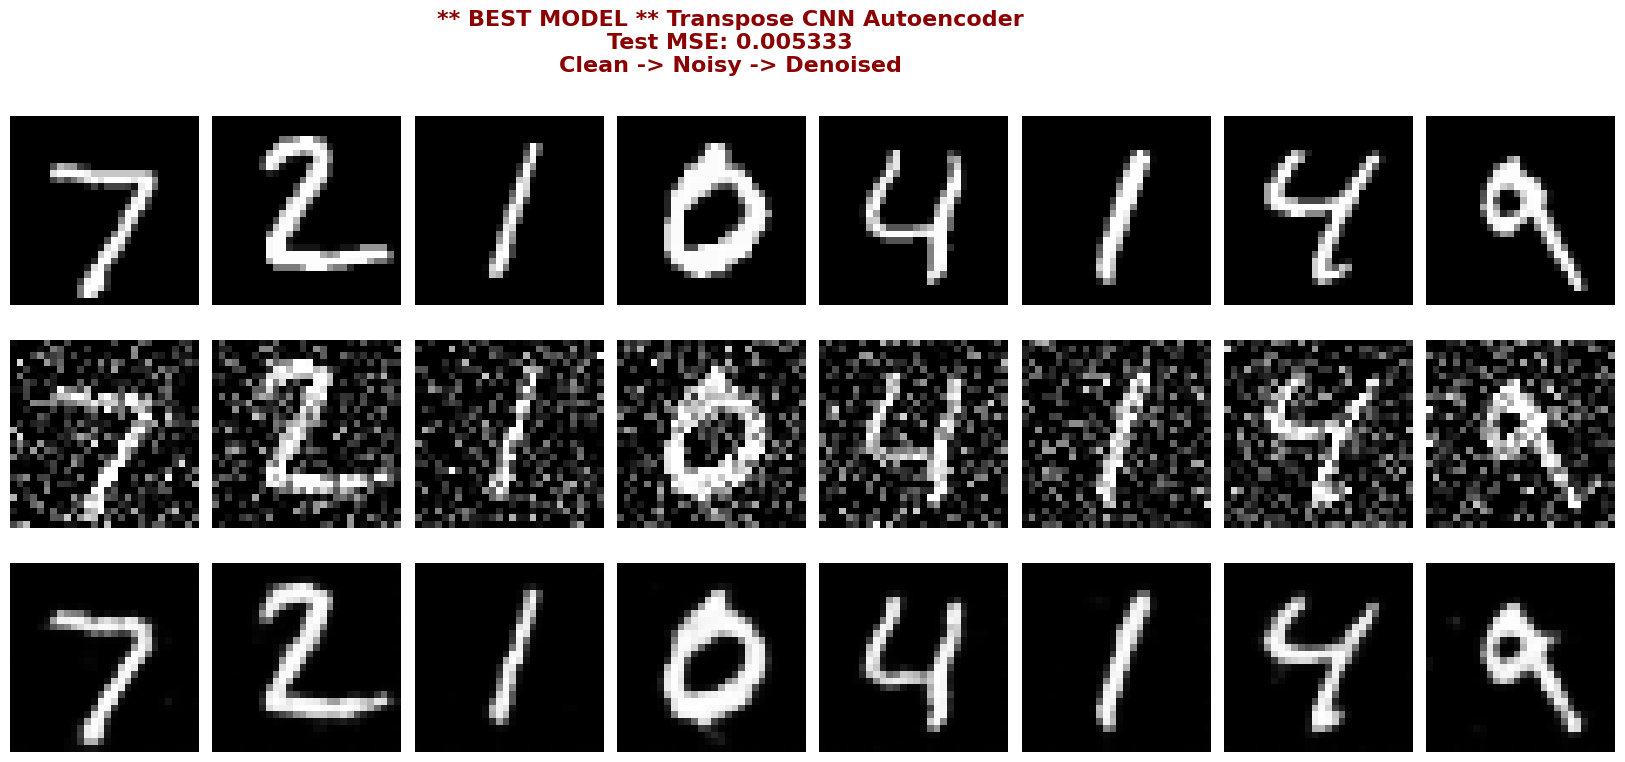

Visual results for best model completed!


In [13]:
print(f"Loading best model: {all_res[best_m]['model_name']}...")
best_model=all_res[best_m]['model']
best_model.load_state_dict(torch.load(f'best_{best_m}_model.pth'))
best_model.eval()

print(f"Testing the {all_res[best_m]['model_name']}...")

with torch.no_grad():
    test_iter=iter(te_loader)
    noisy_batch,clean_batch=next(test_iter)
    noisy_batch=noisy_batch.to(device)
    clean_batch=clean_batch.to(device)
    denoised_batch=best_model(noisy_batch)
    noisy_np=noisy_batch.cpu().numpy()
    clean_np=clean_batch.cpu().numpy()
    denoised_np=denoised_batch.cpu().numpy()

n_samples=8
fig,axes=plt.subplots(3,n_samples,figsize=(18,8))

for i in range(n_samples):
    axes[0,i].imshow(clean_np[i,0],cmap='gray')
    axes[0,i].axis('off')
    axes[1,i].imshow(noisy_np[i,0],cmap='gray')
    axes[1,i].axis('off')
    axes[2,i].imshow(denoised_np[i,0],cmap='gray')
    axes[2,i].axis('off')

axes[0,0].set_ylabel('Clean\n(Original)',rotation=0,labelpad=60,ha='right',va='center',fontsize=12)
axes[1,0].set_ylabel('Noisy\n(Input)',rotation=0,labelpad=60,ha='right',va='center',fontsize=12)
axes[2,0].set_ylabel('Denoised\n(Output)',rotation=0,labelpad=60,ha='right',va='center',fontsize=12)

plt.suptitle(f'** BEST MODEL ** {all_res[best_m]["model_name"]}\nTest MSE: {all_res[best_m]["final_test_mse"]:.6f}\nClean -> Noisy -> Denoised',fontsize=16,y=0.98,fontweight='bold',color='darkred')
plt.tight_layout()
plt.subplots_adjust(left=0.1)
plt.show()

print("Visual results for best model completed!")

Generating comparison of all three models' denoising results...


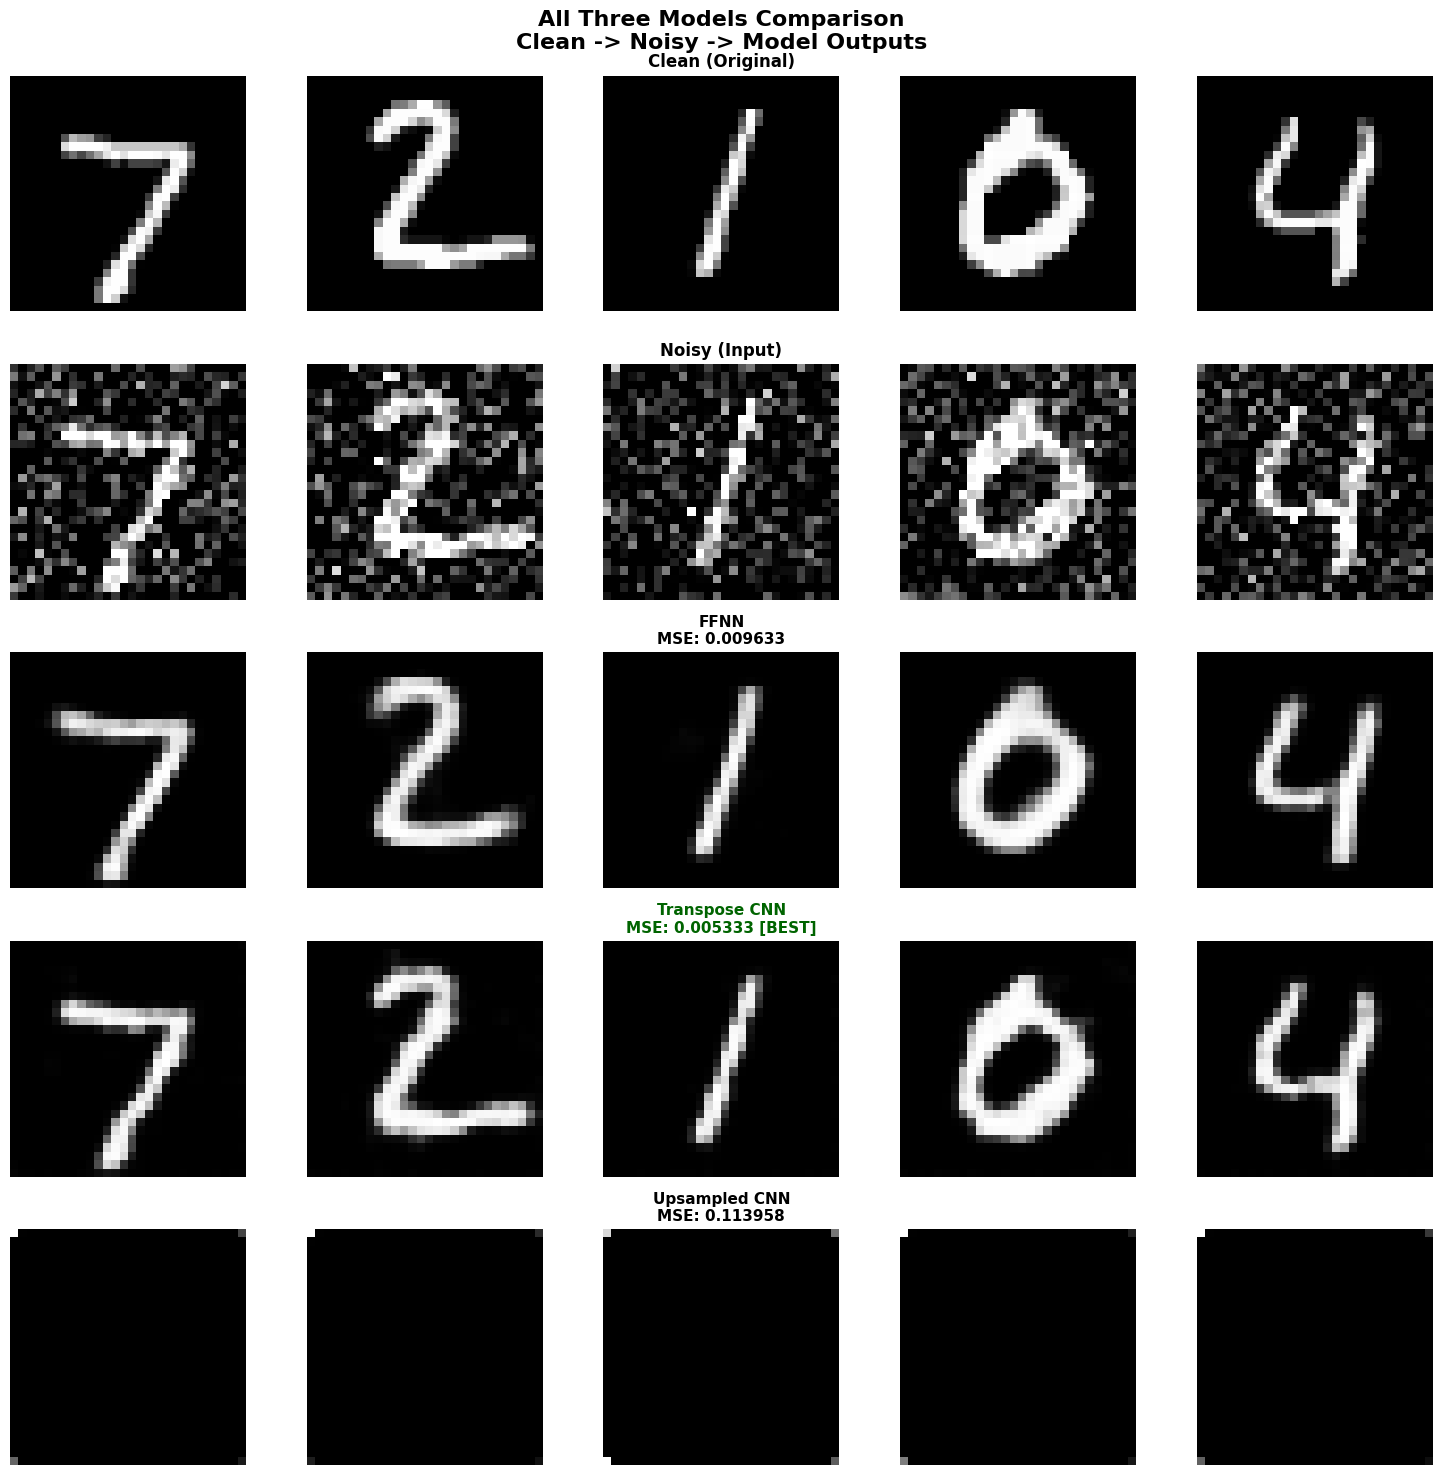

All models comparison visualization completed!


In [14]:
print("Generating comparison of all three models' denoising results...")

with torch.no_grad():
    test_iter=iter(te_loader)
    noisy_batch,clean_batch=next(test_iter)
    noisy_batch_gpu=noisy_batch.to(device)
    clean_batch_gpu=clean_batch.to(device)
    denoised_res={}
    for m_type in m_types:
        model=all_res[m_type]['model']
        model.load_state_dict(torch.load(f'best_{m_type}_model.pth'))
        model.eval()
        denoised_res[m_type]=model(noisy_batch_gpu).cpu().numpy()
    noisy_np=noisy_batch.numpy()
    clean_np=clean_batch.numpy()

n_samples=5
fig,axes=plt.subplots(5,n_samples,figsize=(15,15))

for i in range(n_samples):
    axes[0,i].imshow(clean_np[i,0],cmap='gray')
    axes[0,i].axis('off')
    if i==2:
        axes[0,i].set_title('Clean (Original)',fontsize=12,fontweight='bold')
    axes[1,i].imshow(noisy_np[i,0],cmap='gray')
    axes[1,i].axis('off')
    if i==2:
        axes[1,i].set_title('Noisy (Input)',fontsize=12,fontweight='bold')
    axes[2,i].imshow(denoised_res['ffnn'][i,0],cmap='gray')
    axes[2,i].axis('off')
    if i==2:
        mse=all_res['ffnn']['final_test_mse']
        title_color='darkgreen' if best_m=='ffnn' else 'black'
        title_text=f'FFNN\nMSE: {mse:.6f}'
        if best_m=='ffnn':
            title_text+=' [BEST]'
        axes[2,i].set_title(title_text,fontsize=11,fontweight='bold',color=title_color)
    axes[3,i].imshow(denoised_res['transpose_cnn'][i,0],cmap='gray')
    axes[3,i].axis('off')
    if i==2:
        mse=all_res['transpose_cnn']['final_test_mse']
        title_color='darkgreen' if best_m=='transpose_cnn' else 'black'
        title_text=f'Transpose CNN\nMSE: {mse:.6f}'
        if best_m=='transpose_cnn':
            title_text+=' [BEST]'
        axes[3,i].set_title(title_text,fontsize=11,fontweight='bold',color=title_color)
    axes[4,i].imshow(denoised_res['upsampled_cnn'][i,0],cmap='gray')
    axes[4,i].axis('off')
    if i==2:
        mse=all_res['upsampled_cnn']['final_test_mse']
        title_color='darkgreen' if best_m=='upsampled_cnn' else 'black'
        title_text=f'Upsampled CNN\nMSE: {mse:.6f}'
        if best_m=='upsampled_cnn':
            title_text+=' [BEST]'
        axes[4,i].set_title(title_text,fontsize=11,fontweight='bold',color=title_color)

plt.suptitle('All Three Models Comparison\nClean -> Noisy -> Model Outputs',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

print("All models comparison visualization completed!")

In [15]:
print("\n"+"="*80)
print("                         FINAL COMPREHENSIVE REPORT")
print("="*80)

for m_type in m_types:
    res=all_res[m_type]
    is_best=(m_type==best_m)
    if is_best:
        print(f"\n{'='*80}")
        print(f"   MODEL: {res['model_name']} (BEST MODEL)")
    else:
        print(f"\n{'='*80}")
        print(f"   MODEL: {res['model_name']}")
    print("="*80)
    print(f"   Architecture        : {m_type.upper().replace('_',' ')}")
    print(f"   Total Parameters    : {res['total_params']:,}")
    print(f"   Trainable Parameters: {res['total_params']:,}")
    print(f"   ")
    print(f"   Training Performance:")
    print(f"   - Starting Train Loss  : {res['train_losses'][0]:.6f}")
    print(f"   - Final Train Loss     : {res['train_losses'][-1]:.6f}")
    print(f"   - Train Improvement    : {((res['train_losses'][0]-res['train_losses'][-1])/res['train_losses'][0]*100):.1f}%")
    print(f"   ")
    print(f"   Validation Performance:")
    print(f"   - Starting Val Loss    : {res['val_losses'][0]:.6f}")
    print(f"   - Best Val Loss        : {res['best_val_loss']:.6f}")
    print(f"   - Val Improvement      : {((res['val_losses'][0]-res['best_val_loss'])/res['val_losses'][0]*100):.1f}%")
    print(f"   ")
    print(f"   Test Performance:")
    print(f"   - Final Test MSE       : {res['final_test_mse']:.6f}")
    print(f"   ")
    print(f"   Visual Artifacts       : {res['artifacts']}")
    print("="*80)

print("\n"+"="*80)
print("                     FINAL COMPARISON")
print("="*80)
print(f"\n{'Rank':<6} {'Model':<30} {'Test MSE':<15} {'Parameters':<15}")
print("-"*80)

sorted_models=sorted(m_types,key=lambda k:all_res[k]['final_test_mse'])

for rank,m_type in enumerate(sorted_models,1):
    res=all_res[m_type]
    medal="1st" if rank==1 else "2nd" if rank==2 else "3rd"
    print(f"{medal} {rank:<4} {res['model_name']:<30} {res['final_test_mse']:<15.6f} {res['total_params']:<15,}")

print("="*80)

print("\n"+"="*80)
print("                      KEY FINDINGS")
print("="*80)

best_res=all_res[best_m]
worst_m=max(all_res.keys(),key=lambda k:all_res[k]['final_test_mse'])
worst_res=all_res[worst_m]

improvement=((worst_res['final_test_mse']-best_res['final_test_mse'])/worst_res['final_test_mse']*100)

print(f"\n1. BEST PERFORMING MODEL:")
print(f"   {best_res['model_name']} achieved the lowest Test MSE of {best_res['final_test_mse']:.6f}")
print(f"   with {best_res['total_params']:,} parameters.")

print(f"\n2. PERFORMANCE IMPROVEMENT:")
print(f"   The best model ({best_res['model_name']}) performs {improvement:.1f}% better")
print(f"   than the worst model ({worst_res['model_name']}).")

print(f"\n3. EFFICIENCY:")
smallest_m=min(m_types,key=lambda k:all_res[k]['total_params'])
print(f"   {all_res[smallest_m]['model_name']} has the fewest parameters")
print(f"   ({all_res[smallest_m]['total_params']:,}) while achieving")
print(f"   Test MSE of {all_res[smallest_m]['final_test_mse']:.6f}")

print(f"\n4. RECOMMENDATION:")
if best_res['artifacts']=='None':
    print(f"   {best_res['model_name']} is recommended for deployment.")
    print(f"   It has the best performance with no visual artifacts.")
else:
    print(f"   {best_res['model_name']} has the best performance but may have artifacts.")
    alternative=[mt for mt in sorted_models if all_res[mt]['artifacts']=='None'][0]
    print(f"   Consider {all_res[alternative]['model_name']} as an alternative")
    print(f"   (Test MSE: {all_res[alternative]['final_test_mse']:.6f}, No artifacts)")

print("\n"+"="*80)
print("                      TRAINING COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n All results have been saved:")
for m_type in m_types:
    print(f"   {m_type}_complete_results.pth")
print(f"   model_comparison_summary.pth")
print("\n"+"="*80)


                         FINAL COMPREHENSIVE REPORT

   MODEL: FFNN Autoencoder
   Architecture        : FFNN
   Total Parameters    : 1,100,112
   Trainable Parameters: 1,100,112
   
   Training Performance:
   - Starting Train Loss  : 0.042020
   - Final Train Loss     : 0.009696
   - Train Improvement    : 76.9%
   
   Validation Performance:
   - Starting Val Loss    : 0.025899
   - Best Val Loss        : 0.009638
   - Val Improvement      : 62.8%
   
   Test Performance:
   - Final Test MSE       : 0.009633
   
   Visual Artifacts       : None

   MODEL: Transpose CNN Autoencoder (BEST MODEL)
   Architecture        : TRANSPOSE CNN
   Total Parameters    : 9,569
   Trainable Parameters: 9,569
   
   Training Performance:
   - Starting Train Loss  : 0.030173
   - Final Train Loss     : 0.005364
   - Train Improvement    : 82.2%
   
   Validation Performance:
   - Starting Val Loss    : 0.006295
   - Best Val Loss        : 0.005299
   - Val Improvement      : 15.8%
   
   Test Perfo